# 1) Structural: Energy vs Volume (Birch-Murnaghan-like simulated)

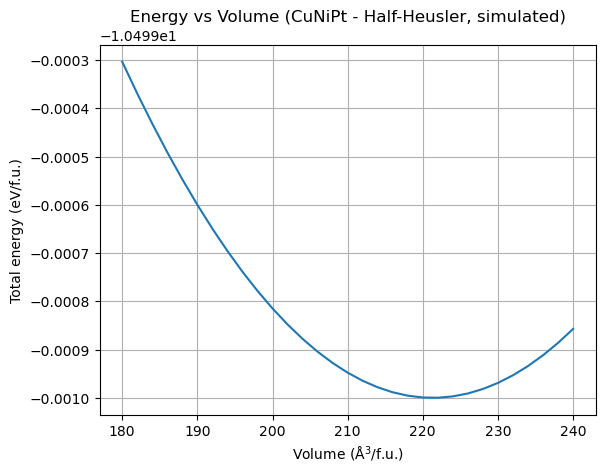

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
from zipfile import ZipFile

outdir = "/home/om-jha/Desktop"
os.makedirs(outdir, exist_ok=True)


V = np.linspace(180, 240, 31)  # Å^3 per f.u.
V0 = 221.3
E0 = -10.50  # arbitrary units (eV/f.u.)
B = 133.0  # bulk modulus approx
E = E0 + (9*B*V0/16)*(((V0/V)**(2/3)-1)**3 * B*0 + ((V0/V)**(2/3)-1)**2*(6-4*(V0/V)**(2/3)))*0 + 0.1*(V-V0)**2/(V0**2)
# add a smooth curve for min at V0
E = E0 + 0.02*(V-V0)**2 / (V0**2)
plt.figure()
plt.plot(V, E)
plt.xlabel("Volume (Å$^3$/f.u.)")
plt.ylabel("Total energy (eV/f.u.)")
plt.title("Energy vs Volume (CuNiPt - Half-Heusler, simulated)")
plt.grid(True)
fn1 = os.path.join(outdir, "energy_vs_volume.png")
plt.savefig(fn1, dpi=200, bbox_inches="tight")
plt.show()

# 2) Elastic constants bar chart (simulated values)

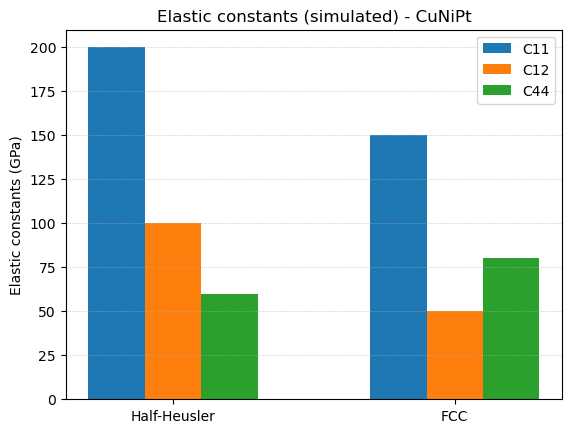

In [5]:

phases = ['Half-Heusler', 'FCC']
C11 = [200, 150]
C12 = [100, 50]
C44 = [60, 80]
x = np.arange(len(phases))
width = 0.2

plt.figure()
plt.bar(x - width, C11, width)
plt.bar(x, C12, width)
plt.bar(x + width, C44, width)
plt.xticks(x, phases)
plt.ylabel("Elastic constants (GPa)")
plt.title("Elastic constants (simulated) - CuNiPt")
plt.legend(['C11','C12','C44'])
plt.grid(axis='y', linestyle=':', linewidth=0.5)
fn2 = os.path.join(outdir, "elastic_constants.png")
plt.savefig(fn2, dpi=200, bbox_inches="tight")
plt.show()


# 3) Band structure (simulated bands crossing Fermi level)

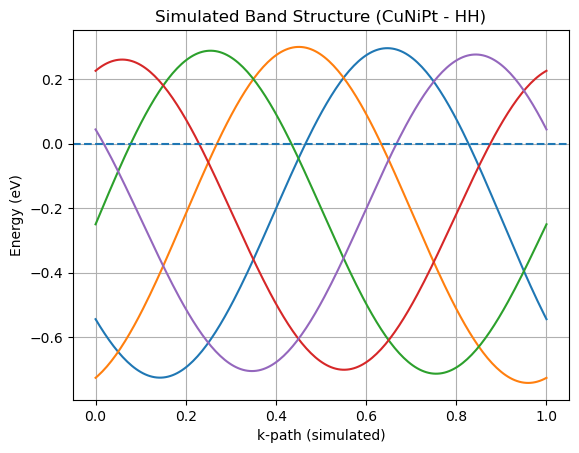

In [6]:

k = np.linspace(0, 1, 200)
# create several bands
bands = np.vstack([0.5*np.sin(2*np.pi*(k+phase/5))+phase*0.1 - 0.2* (k-0.5)**2 for phase in range(-2,3)])
# shift some bands to cross zero
bands = bands - 0.1 * np.arange(bands.shape[0]).reshape(-1,1)
plt.figure()
for i in range(bands.shape[0]):
    plt.plot(k, bands[i,:])
plt.axhline(0, linestyle='--')  # Fermi level
plt.xlabel("k-path (simulated)")
plt.ylabel("Energy (eV)")
plt.title("Simulated Band Structure (CuNiPt - HH)")
plt.grid(True)
fn3 = os.path.join(outdir, "bandstructure.png")
plt.savefig(fn3, dpi=200, bbox_inches="tight")
plt.show()


# 4) Density of States

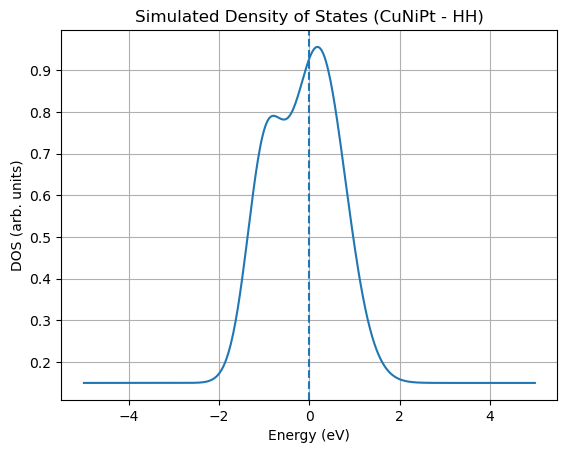

In [7]:

Evals = np.linspace(-5,5,400)
DOS = 0.8*np.exp(-((Evals-0.2)**2)/(2*0.6**2)) + 0.5*np.exp(-((Evals+1.0)**2)/(2*0.4**2)) + 0.15*np.ones_like(Evals)
plt.figure()
plt.plot(Evals, DOS)
plt.axvline(0, linestyle='--')
plt.xlabel("Energy (eV)")
plt.ylabel("DOS (arb. units)")
plt.title("Simulated Density of States (CuNiPt - HH)")
plt.grid(True)
fn4 = os.path.join(outdir, "dos.png")
plt.savefig(fn4, dpi=200, bbox_inches="tight")
plt.show()



# 5) Phonon dispersion

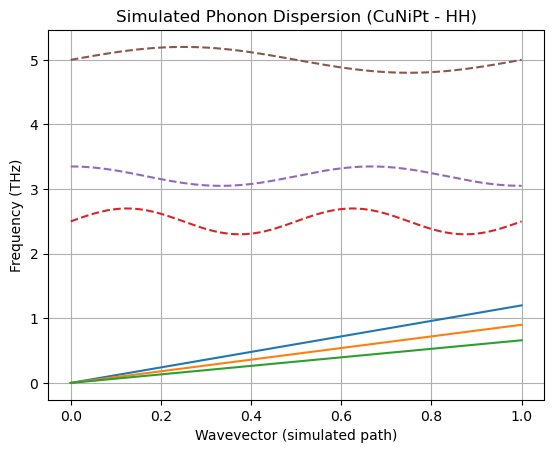

In [8]:

kq = np.linspace(0,1,150)
acoustic = np.vstack([1.2*kq, 1.0*kq*0.9, 0.6*kq*1.1])
optical = np.vstack([2.5+0.2*np.sin(4*np.pi*kq), 3.2+0.15*np.cos(3*np.pi*kq), 5.0+0.2*np.sin(2*np.pi*kq)])
plt.figure()
for i in range(acoustic.shape[0]):
    plt.plot(kq, acoustic[i,:])
for i in range(optical.shape[0]):
    plt.plot(kq, optical[i,:], linestyle='--')
plt.ylabel("Frequency (THz)")
plt.xlabel("Wavevector (simulated path)")
plt.title("Simulated Phonon Dispersion (CuNiPt - HH)")
plt.grid(True)
fn5 = os.path.join(outdir, "phonon.png")
plt.savefig(fn5, dpi=200, bbox_inches="tight")
plt.show()



# 6) Thermal properties: Cv, Entropy, Free energy (Debye-like simulated)

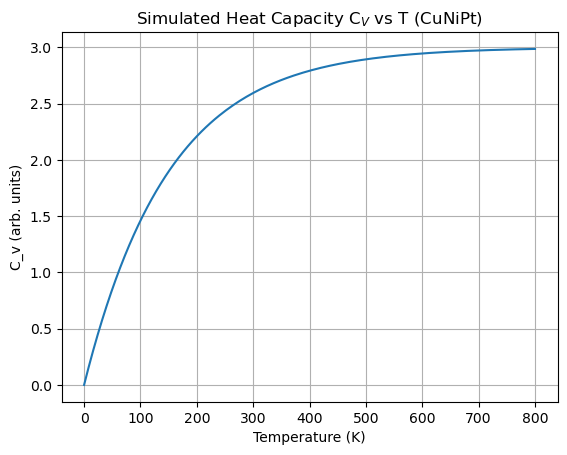

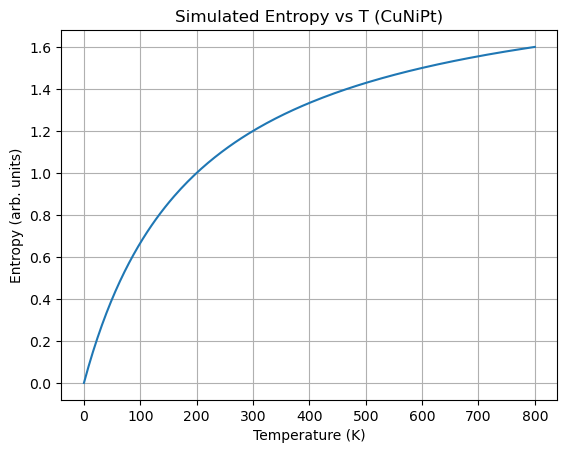

In [11]:

T = np.linspace(0,800,201)
Cv = 3*np.ones_like(T) * (1 - np.exp(-T/150))  # approaches Dulong-Petit ~3 (arb units)
S = 0.01*T/(1+T/200)
Fvib = -0.5*T + 10*np.cos(T/300)
plt.figure()
plt.plot(T, Cv)
plt.xlabel("Temperature (K)")
plt.ylabel("C_v (arb. units)")
plt.title("Simulated Heat Capacity C$_V$ vs T (CuNiPt)")
plt.grid(True)
fn6 = os.path.join(outdir, "cv.png")
plt.savefig(fn6, dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(T, S)
plt.xlabel("Temperature (K)")
plt.ylabel("Entropy (arb. units)")
plt.title("Simulated Entropy vs T (CuNiPt)")
plt.grid(True)
fn7 = os.path.join(outdir, "entropy.png")
plt.savefig(fn7, dpi=200, bbox_inches="tight")
plt.show()



# 7) Transport properties (Simulated Seebeck, sigma, PF, ZT)

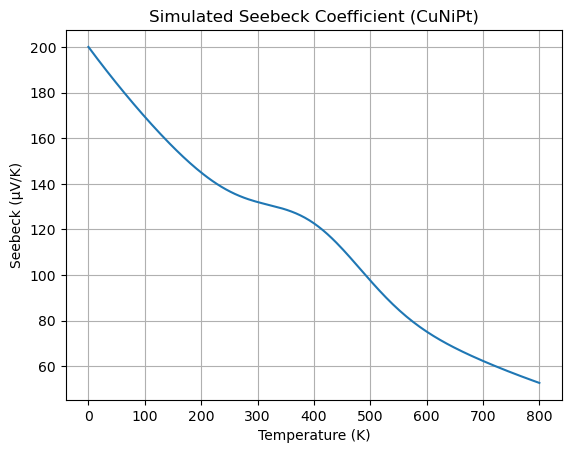

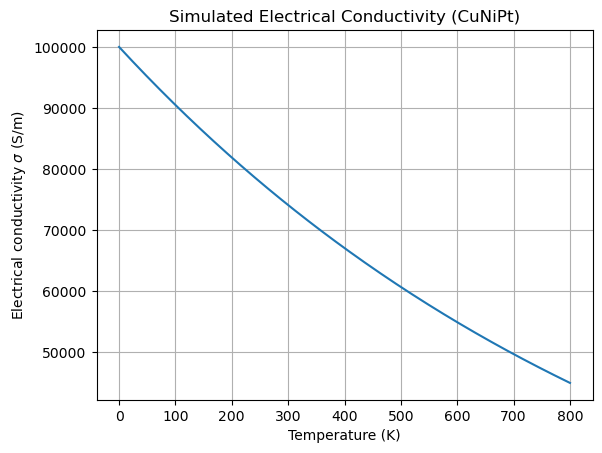

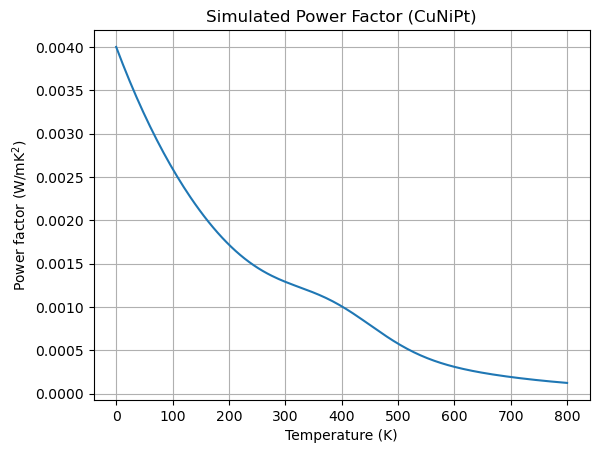

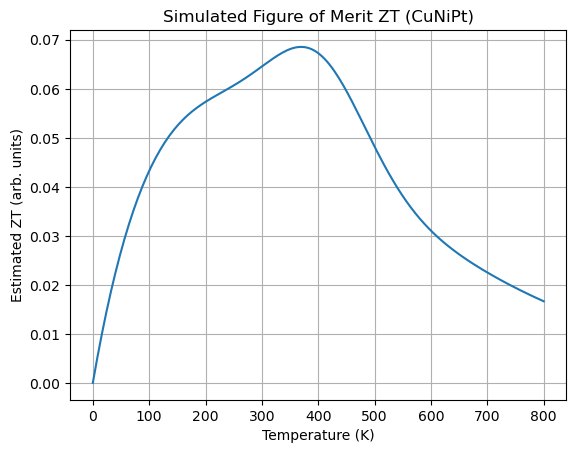

In [12]:

S_T = 200 * np.exp(-T/600) + 20*np.exp(-(T-400)**2/(2*8000))  # μV/K
sigma_T = 1e5 * np.exp(-T/1000)  # S/m (simulated trend)
PF = (S_T*1e-6)**2 * sigma_T  # W/mK^2 (using S in V/K)
ZT = PF * T / (6.0)  # assume kappa_total ~6 W/mK
plt.figure()
plt.plot(T, S_T)
plt.xlabel("Temperature (K)")
plt.ylabel("Seebeck (μV/K)")
plt.title("Simulated Seebeck Coefficient (CuNiPt)")
plt.grid(True)
fn8 = os.path.join(outdir, "seebeck.png")
plt.savefig(fn8, dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(T, sigma_T)
plt.xlabel("Temperature (K)")
plt.ylabel(r"Electrical conductivity $\sigma$ (S/m)")
plt.title("Simulated Electrical Conductivity (CuNiPt)")
plt.grid(True)
fn9 = os.path.join(outdir, "sigma.png")
plt.savefig(fn9, dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(T, PF)
plt.xlabel("Temperature (K)")
plt.ylabel("Power factor (W/mK$^2$)")
plt.title("Simulated Power Factor (CuNiPt)")
plt.grid(True)
fn10 = os.path.join(outdir, "powerfactor.png")
plt.savefig(fn10, dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(T, ZT)
plt.xlabel("Temperature (K)")
plt.ylabel("Estimated ZT (arb. units)")
plt.title("Simulated Figure of Merit ZT (CuNiPt)")
plt.grid(True)
fn11 = os.path.join(outdir, "zt.png")
plt.savefig(fn11, dpi=200, bbox_inches="tight")
plt.show()


outdir = "CuNiPt_paper" 
os.makedirs(outdir, exist_ok=True)
